# 🌦️ Phân Tích Khám Phá Dữ Liệu (EDA) - Thời Tiết Việt Nam

---

> **Nhóm thực hiện:** DataVis - WeatherVietNam  
> **Năm:** 2026  
> **Mục tiêu:** Khám phá, hiểu và trực quan hóa bộ dữ liệu thời tiết Việt Nam để rút ra các insight phục vụ thiết kế Dashboard.


## 📦 Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Thư viện đã được import thành công!')

✅ Thư viện đã được import thành công!


---

## 1. 📋 Giới Thiệu Dữ Liệu


### 1.1 Nguồn dữ liệu

| Mục | Nội dung |
|-----|----------|
| **Tên tập dữ liệu** | WeatherVietNam - `datasetall.csv` |
| **Phạm vi địa lý** | 63 tỉnh/thành phố Việt Nam |
| **Phạm vi thời gian** | Năm 2024 (dữ liệu hàng ngày) |
| **Nguồn** | Tổng hợp từ API thời tiết (Open-Meteo / OpenWeatherMap) |
| **Đơn vị thời gian** | Hàng ngày (daily) |

### 1.2 Mô tả các bảng

Tập dữ liệu bao gồm **1 bảng duy nhất** (`datasetall.csv`) chứa thông tin thời tiết và chất lượng không khí theo ngày của từng tỉnh/thành.

### 1.3 Ý nghĩa từng biến

| Tên cột | Kiểu dữ liệu | Ý nghĩa | Đơn vị |
|---------|-------------|---------|--------|
| `date` | datetime | Ngày ghi nhận dữ liệu | YYYY-MM-DD |
| `city_id` | int | Mã định danh thành phố | - |
| `province` | string | Tên tỉnh/thành phố | - |
| `country` | string | Tên quốc gia | - |
| `latitude` | float | Vĩ độ địa lý | độ (°) |
| `longitude` | float | Kinh độ địa lý | độ (°) |
| `temperature_max` | float | Nhiệt độ cao nhất trong ngày | °C |
| `temperature_min` | float | Nhiệt độ thấp nhất trong ngày | °C |
| `temperature_mean` | float | Nhiệt độ trung bình trong ngày | °C |
| `rain_sum` | float | Tổng lượng mưa trong ngày | mm |
| `humidity_mean` | float | Độ ẩm trung bình trong ngày | % |
| `wind_speed_max` | float | Tốc độ gió tối đa trong ngày | km/h |
| `aqi` | int | Chỉ số chất lượng không khí (AQI) | 0-500 |
| `cloud_cover_mean` | float | Độ che phủ mây trung bình | % |


---

## 2. 🔍 Tổng Quan Dữ Liệu


In [3]:
# Load dữ liệu
DATA_PATH = '../backend/data/datasetall.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print(f'✅ Đọc dữ liệu thành công!')
print(f'📊 Shape: {df.shape[0]:,} dòng × {df.shape[1]} cột')

✅ Đọc dữ liệu thành công!
📊 Shape: 58,887 dòng × 14 cột


### 2.1 Xem trước dữ liệu — `df.head()`

In [4]:
df.head(10)

,date,city_id,province,country,latitude,longitude,temperature_max,temperature_min,temperature_mean,rain_sum,humidity_mean,wind_speed_max,aqi,cloud_cover_mean
0,2024-01-01,707,Bắc Ninh,Viet Nam,21.1861,106.0763,26.3,17.7,21.8,0.0,80,15.6,75,52
1,2024-01-01,590,Đà Nẵng,Viet Nam,16.0471,108.2068,25.3,22.5,23.7,3.9,86,15.8,36,91
2,2024-01-01,365,Cà Mau,Viet Nam,9.1769,105.1501,31.1,23.1,26.8,1.5,78,19.5,26,97
3,2024-01-01,278,Đồng Nai,Viet Nam,10.9575,106.8427,32.1,23.6,27.4,0.0,76,11.3,68,100
4,2024-01-01,347,Bình Phước,Viet Nam,11.7516,106.8778,32.6,21.7,26.8,0.0,69,10.7,32,88
5,2024-01-01,811,Điện Biên,Viet Nam,21.3833,103.0167,27.5,11.8,19.2,0.0,73,6.8,21,10
6,2024-01-01,132,Đắk Nông,Viet Nam,12.0000,107.7000,29.1,18.0,22.7,0.0,77,9.9,19,97
7,2024-01-01,620,Cần Thơ,Viet Nam,10.0451,105.7462,31.0,23.4,27.0,1.0,80,12.4,51,100
8,2024-01-01,133,Bình Định,Viet Nam,13.7820,109.2194,26.9,22.4,24.2,1.1,86,17.1,28,91
9,2024-01-01,951,Bình Dương,Viet Nam,11.0531,106.6661,32.1,22.9,27.1,0.0,76,7.8,66,99


### 2.2 Thông tin tổng quan — `df.info()`

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58887 entries, 0 to 58886
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              58887 non-null  datetime64[us]
 1   city_id           58887 non-null  int64         
 2   province          58887 non-null  str           
 3   country           58887 non-null  str           
 4   latitude          58887 non-null  float64       
 5   longitude         58887 non-null  float64       
 6   temperature_max   58887 non-null  float64       
 7   temperature_min   58887 non-null  float64       
 8   temperature_mean  58887 non-null  float64       
 9   rain_sum          58887 non-null  float64       
 10  humidity_mean     58887 non-null  int64         
 11  wind_speed_max    58887 non-null  float64       
 12  aqi               58887 non-null  int64         
 13  cloud_cover_mean  58887 non-null  int64         
dtypes: datetime64[us](1), float64(7),

### 2.3 Thống kê mô tả — `df.describe()`

In [6]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', '50%']).format(precision=2)

TypeError: float() argument must be a string or a real number, not 'Timestamp'

### 2.4 Tổng hợp: Shape, Kiểu dữ liệu, Memory Usage

In [7]:
print('=' * 55)
print(f'  📐 Shape         : {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'  💾 Memory Usage  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'  📅 Thời gian     : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  🏙️  Số tỉnh/thành : {df["province"].nunique()} tỉnh')
print(f'  📆 Số ngày       : {df["date"].nunique()} ngày')
print('=' * 55)
print('\n📌 Kiểu dữ liệu từng cột:')
dtype_df = pd.DataFrame({
    'Cột': df.dtypes.index,
    'Kiểu dữ liệu': df.dtypes.values,
    'Số giá trị không null': df.count().values,
    'Số giá trị null': df.isnull().sum().values
})
display(dtype_df)

  📐 Shape         : 58,887 dòng × 14 cột
  💾 Memory Usage  : 7.35 MB
  📅 Thời gian     : 2024-01-01 → 2026-07-23
  🏙️  Số tỉnh/thành : 63 tỉnh
  📆 Số ngày       : 935 ngày

📌 Kiểu dữ liệu từng cột:


,Cột,Kiểu dữ liệu,Số giá trị không null,Số giá trị null
0,date,datetime64[us],58887,0
1,city_id,int64,58887,0
2,province,str,58887,0
3,country,str,58887,0
4,latitude,float64,58887,0
5,longitude,float64,58887,0
6,temperature_max,float64,58887,0
7,temperature_min,float64,58887,0
8,temperature_mean,float64,58887,0
9,rain_sum,float64,58887,0


---

## 3. 🔬 Kiểm Tra Chất Lượng Dữ Liệu


### 3.1 Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('✅ Không có giá trị thiếu trong tập dữ liệu!')
else:
    print('⚠️  Các cột có giá trị thiếu:')
    display(missing_df)

print(f'\n📊 Tổng số giá trị thiếu: {df.isnull().sum().sum()}')

✅ Không có giá trị thiếu trong tập dữ liệu!

📊 Tổng số giá trị thiếu: 0


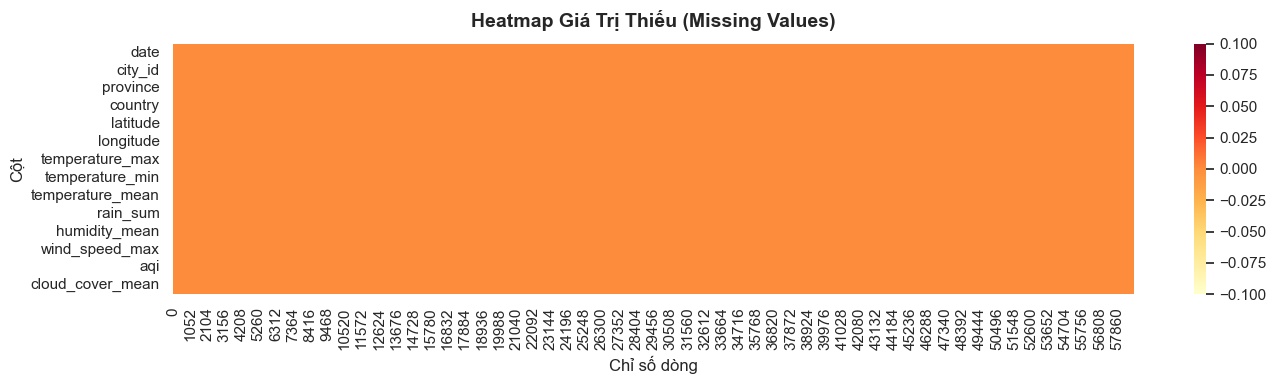

💡 Màu vàng/đỏ = có giá trị thiếu | Màu trắng = không có giá trị thiếu


In [9]:
# Heatmap Missing Values
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df.isnull().T,
    cmap='YlOrRd', cbar=True,
    yticklabels=df.columns, ax=ax
)
ax.set_title('Heatmap Giá Trị Thiếu (Missing Values)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Chỉ số dòng')
ax.set_ylabel('Cột')
plt.tight_layout()
plt.show()
print('💡 Màu vàng/đỏ = có giá trị thiếu | Màu trắng = không có giá trị thiếu')

### 3.2 Duplicate Rows

In [10]:
dup_count = df.duplicated().sum()
print(f'🔁 Số dòng trùng lặp (exact duplicate): {dup_count:,}')
dup_key = df.duplicated(subset=['date', 'province']).sum()
print(f'🔁 Trùng lặp theo (date, province)    : {dup_key:,}')

if dup_count == 0:
    print('\n✅ Không có dòng dữ liệu bị trùng lặp hoàn toàn!')
else:
    print(f'\n⚠️  Cần xem xét {dup_count} dòng bị trùng lặp!')
    display(df[df.duplicated()].head())

🔁 Số dòng trùng lặp (exact duplicate): 52
🔁 Trùng lặp theo (date, province)    : 52

⚠️  Cần xem xét 52 dòng bị trùng lặp!


,date,city_id,province,country,latitude,longitude,temperature_max,temperature_min,temperature_mean,rain_sum,humidity_mean,wind_speed_max,aqi,cloud_cover_mean
1000,2024-01-16,326,Thừa Thiên Huế,Viet Nam,16.4633,107.5847,25.9,18.1,22.0,0.6,81,20.2,34,40
1001,2024-01-16,981,Quảng Bình,Viet Nam,17.4731,106.5962,24.3,19.6,22.2,3.8,82,22.2,37,35
1002,2024-01-16,495,Nghệ An,Viet Nam,18.6667,105.6667,25.0,19.5,21.6,2.3,85,18.9,38,35
1003,2024-01-16,587,Trà Vinh,Viet Nam,9.9342,106.3339,31.1,24.2,26.9,0.0,72,13.7,32,86
1004,2024-01-16,146,Tiền Giang,Viet Nam,10.3606,106.3636,33.1,23.1,26.9,0.0,75,11.8,45,81


### 3.3 Outlier Detection — Boxplot

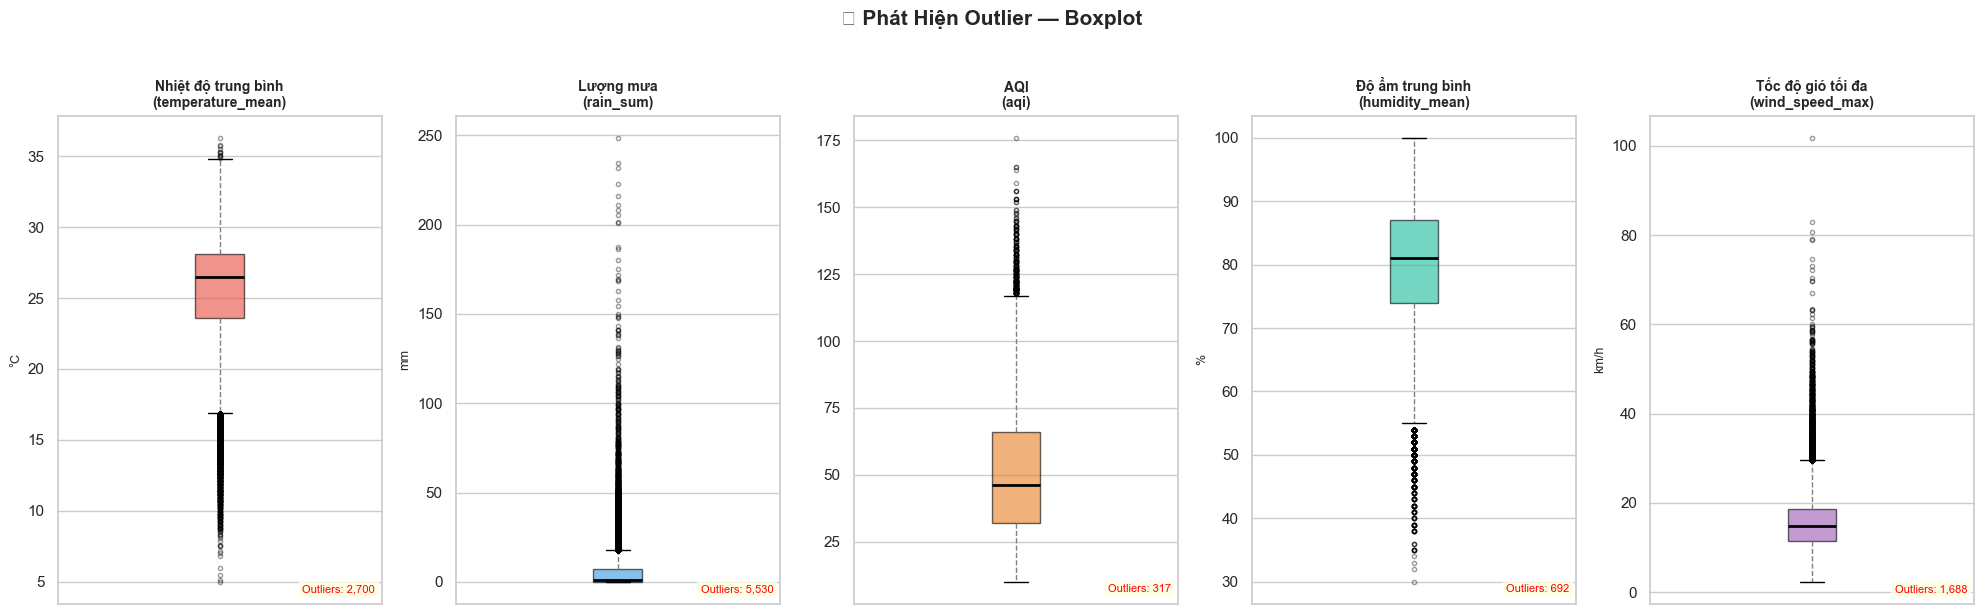

In [11]:
outlier_cols = {
    'temperature_mean': ('Nhiệt độ trung bình', '°C',   '#e74c3c'),
    'rain_sum':         ('Lượng mưa',           'mm',   '#3498db'),
    'aqi':              ('AQI',                  '',     '#e67e22'),
    'humidity_mean':    ('Độ ẩm trung bình',     '%',    '#1abc9c'),
    'wind_speed_max':   ('Tốc độ gió tối đa',   'km/h', '#9b59b6'),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for ax, (col, (label, unit, color)) in zip(axes, outlier_cols.items()):
    data = df[col].dropna()
    bp = ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linestyle='--', color='gray'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4, color=color))
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{label}\n({col})', fontsize=10, fontweight='bold')
    ax.set_ylabel(unit, fontsize=9)
    ax.set_xticks([])
    ax.text(0.98, 0.02, f'Outliers: {n_outliers:,}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('🔍 Phát Hiện Outlier — Boxplot', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Bảng thống kê outlier theo IQR
outlier_stats = []
for col in outlier_cols.keys():
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_stats.append({
        'Cột': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
        'Ngưỡng dưới': round(lower,2), 'Ngưỡng trên': round(upper,2),
        'Số outlier': n_out, 'Tỷ lệ (%)': round(n_out/len(data)*100, 2)
    })

pd.DataFrame(outlier_stats).set_index('Cột').style.background_gradient(cmap='Oranges', subset=['Tỷ lệ (%)'])

,Q1,Q3,IQR,Ngưỡng dưới,Ngưỡng trên,Số outlier,Tỷ lệ (%)
Cột,,,,,,,
temperature_mean,23.600000,28.100000,4.500000,16.850000,34.850000,2700,4.590000
rain_sum,0.000000,7.100000,7.100000,-10.650000,17.750000,5530,9.390000
aqi,32.000000,66.000000,34.000000,-19.000000,117.000000,317,0.540000
humidity_mean,74.000000,87.000000,13.000000,54.500000,106.500000,692,1.180000
wind_speed_max,11.500000,18.700000,7.200000,0.700000,29.500000,1688,2.870000


---

## 4. 📊 Phân Tích Đơn Biến (Univariate Analysis)


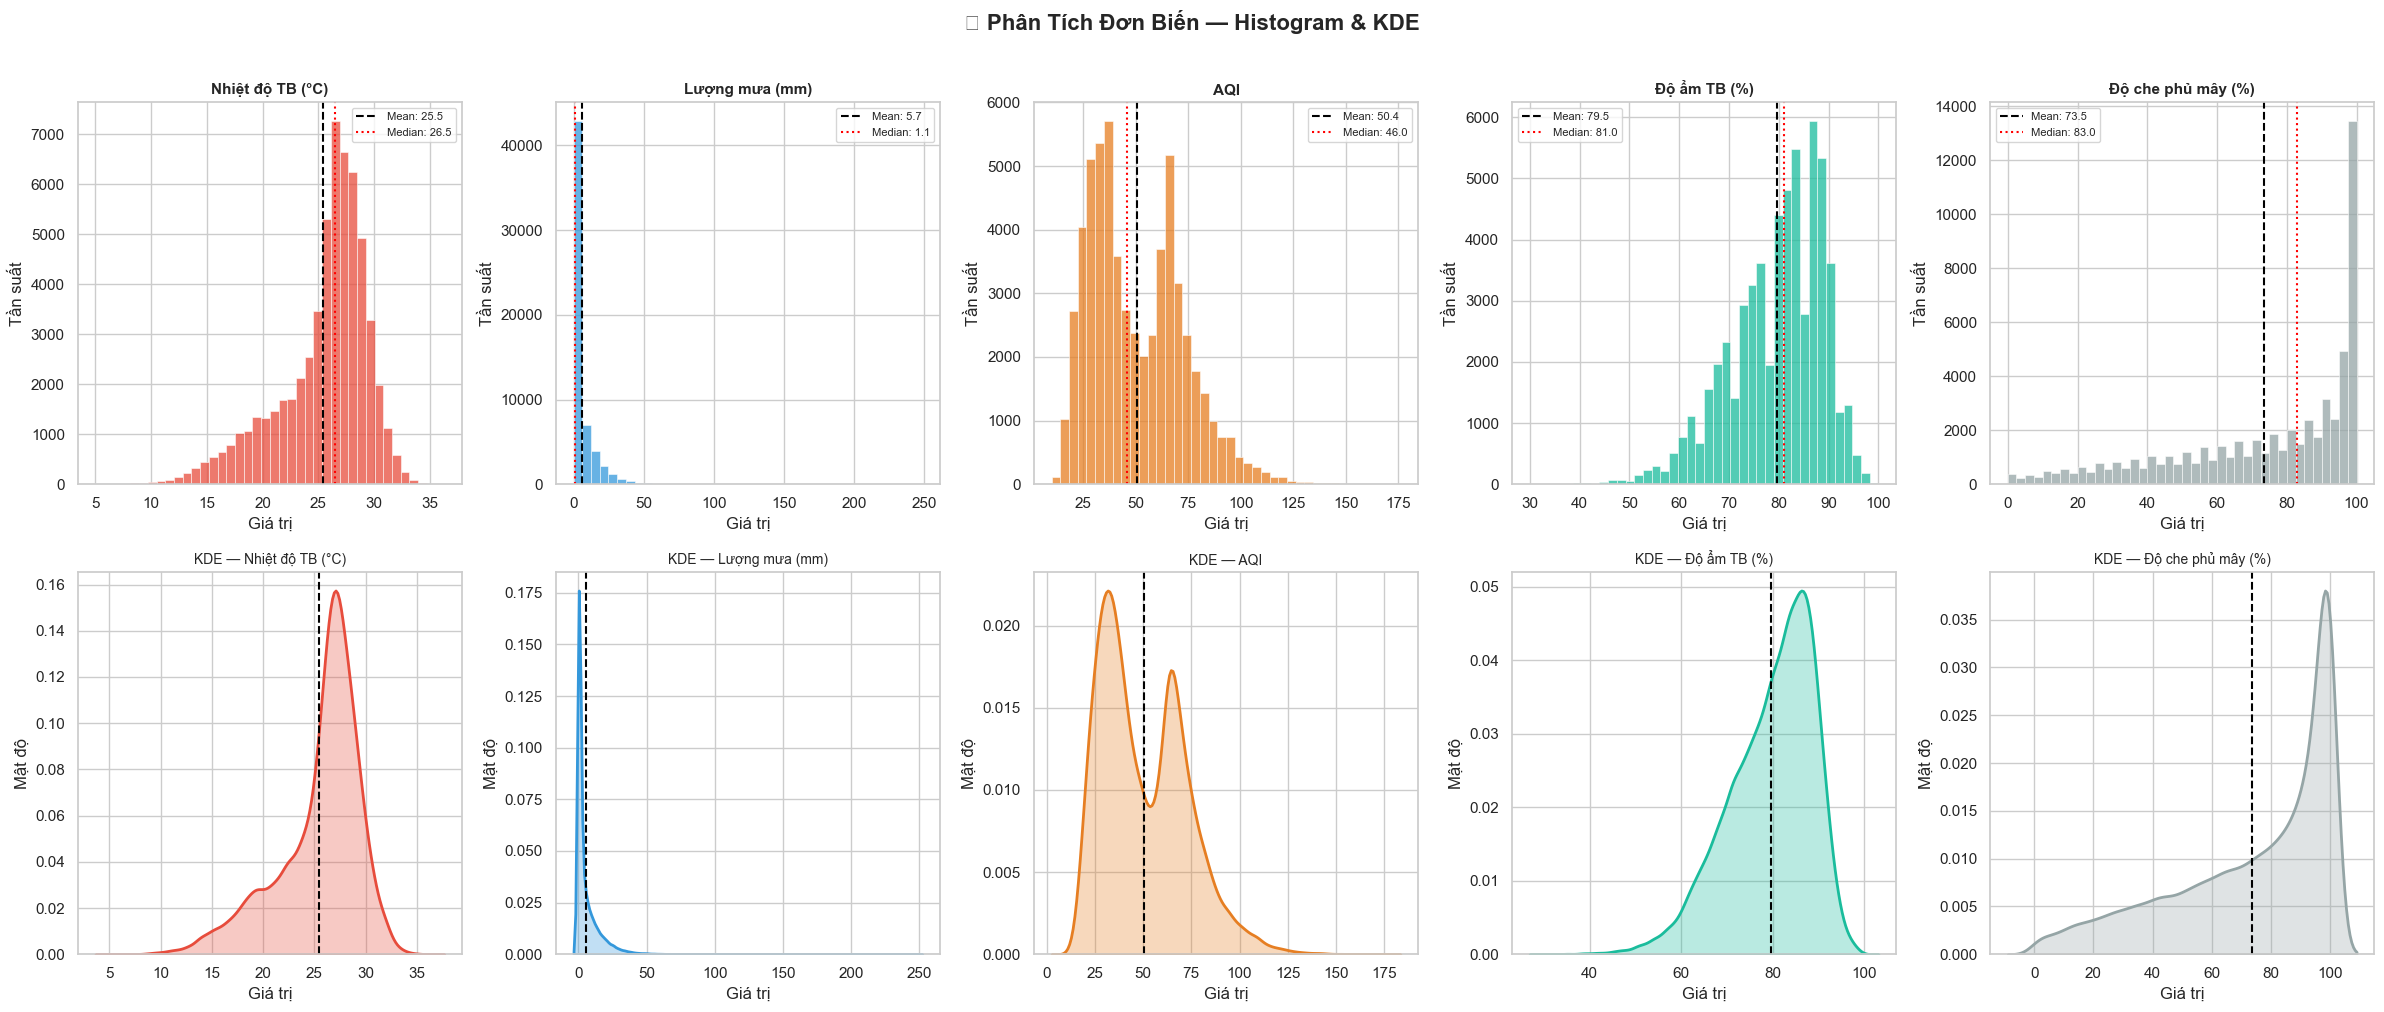

In [13]:
uni_cols = {
    'temperature_mean': ('Nhiệt độ TB (°C)',   '#e74c3c'),
    'rain_sum':         ('Lượng mưa (mm)',      '#3498db'),
    'aqi':              ('AQI',                 '#e67e22'),
    'humidity_mean':    ('Độ ẩm TB (%)',        '#1abc9c'),
    'cloud_cover_mean': ('Độ che phủ mây (%)', '#95a5a6'),
}

fig, axes = plt.subplots(2, 5, figsize=(24, 10))

for i, (col, (label, color)) in enumerate(uni_cols.items()):
    data = df[col].dropna()

    # Histogram
    ax_hist = axes[0, i]
    ax_hist.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax_hist.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax_hist.axvline(data.median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax_hist.set_title(label, fontsize=11, fontweight='bold')
    ax_hist.set_xlabel('Giá trị'); ax_hist.set_ylabel('Tần suất')
    ax_hist.legend(fontsize=8)

    # KDE
    ax_kde = axes[1, i]
    sns.kdeplot(data, ax=ax_kde, color=color, fill=True, alpha=0.3, linewidth=2)
    ax_kde.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5)
    ax_kde.set_title(f'KDE — {label}', fontsize=10)
    ax_kde.set_xlabel('Giá trị'); ax_kde.set_ylabel('Mật độ')

plt.suptitle('📊 Phân Tích Đơn Biến — Histogram & KDE', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# Thống kê mô tả + skewness/kurtosis
key_cols = list(uni_cols.keys())
stats_summary = df[key_cols].describe().T
stats_summary['skewness'] = df[key_cols].skew().values
stats_summary['kurtosis'] = df[key_cols].kurt().values
stats_summary.style.background_gradient(cmap='RdYlGn_r', subset=['skewness']).format(precision=2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
temperature_mean,58887.00,25.46,4.04,5.00,23.60,26.50,28.10,36.30,-1.08,1.04
rain_sum,58887.00,5.69,10.89,0.00,0.00,1.10,7.10,248.70,5.36,57.02
aqi,58887.00,50.42,22.33,10.00,32.00,46.00,66.00,176.00,0.65,0.02
humidity_mean,58887.00,79.54,9.27,30.00,74.00,81.00,87.00,100.00,-0.78,0.44
cloud_cover_mean,58887.00,73.54,26.74,0.00,56.00,83.00,97.00,100.00,-0.91,-0.25


---

## 5. 📅 Phân Tích Theo Thời Gian (Time Series)


In [15]:
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['quarter'] = df['date'].dt.quarter

monthly = df.groupby('month').agg(
    temp_mean=('temperature_mean', 'mean'),
    temp_max=('temperature_max', 'mean'),
    temp_min=('temperature_min', 'mean'),
    rain=('rain_sum', 'mean'),
    aqi=('aqi', 'mean'),
    humidity=('humidity_mean', 'mean'),
    wind=('wind_speed_max', 'mean'),
    cloud=('cloud_cover_mean', 'mean')
).reset_index()

months_label = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
print('✅ Dữ liệu theo tháng đã sẵn sàng!')
monthly.head()

✅ Dữ liệu theo tháng đã sẵn sàng!


,month,temp_mean,temp_max,temp_min,rain,aqi,humidity,wind,cloud
0,1,21.147448,25.408824,17.493412,1.341594,55.254822,75.484554,15.834784,66.099505
1,2,22.703212,26.848590,19.354734,1.583828,48.345472,77.785434,16.522222,67.918954
2,3,24.474876,28.971326,20.919116,1.377027,55.069124,76.020993,16.802048,58.052057
3,4,27.597549,32.460000,23.792434,1.853862,61.523810,74.202469,16.052557,53.626984
4,5,27.785527,31.848251,24.850760,7.249599,51.296126,80.701656,14.710309,79.290152


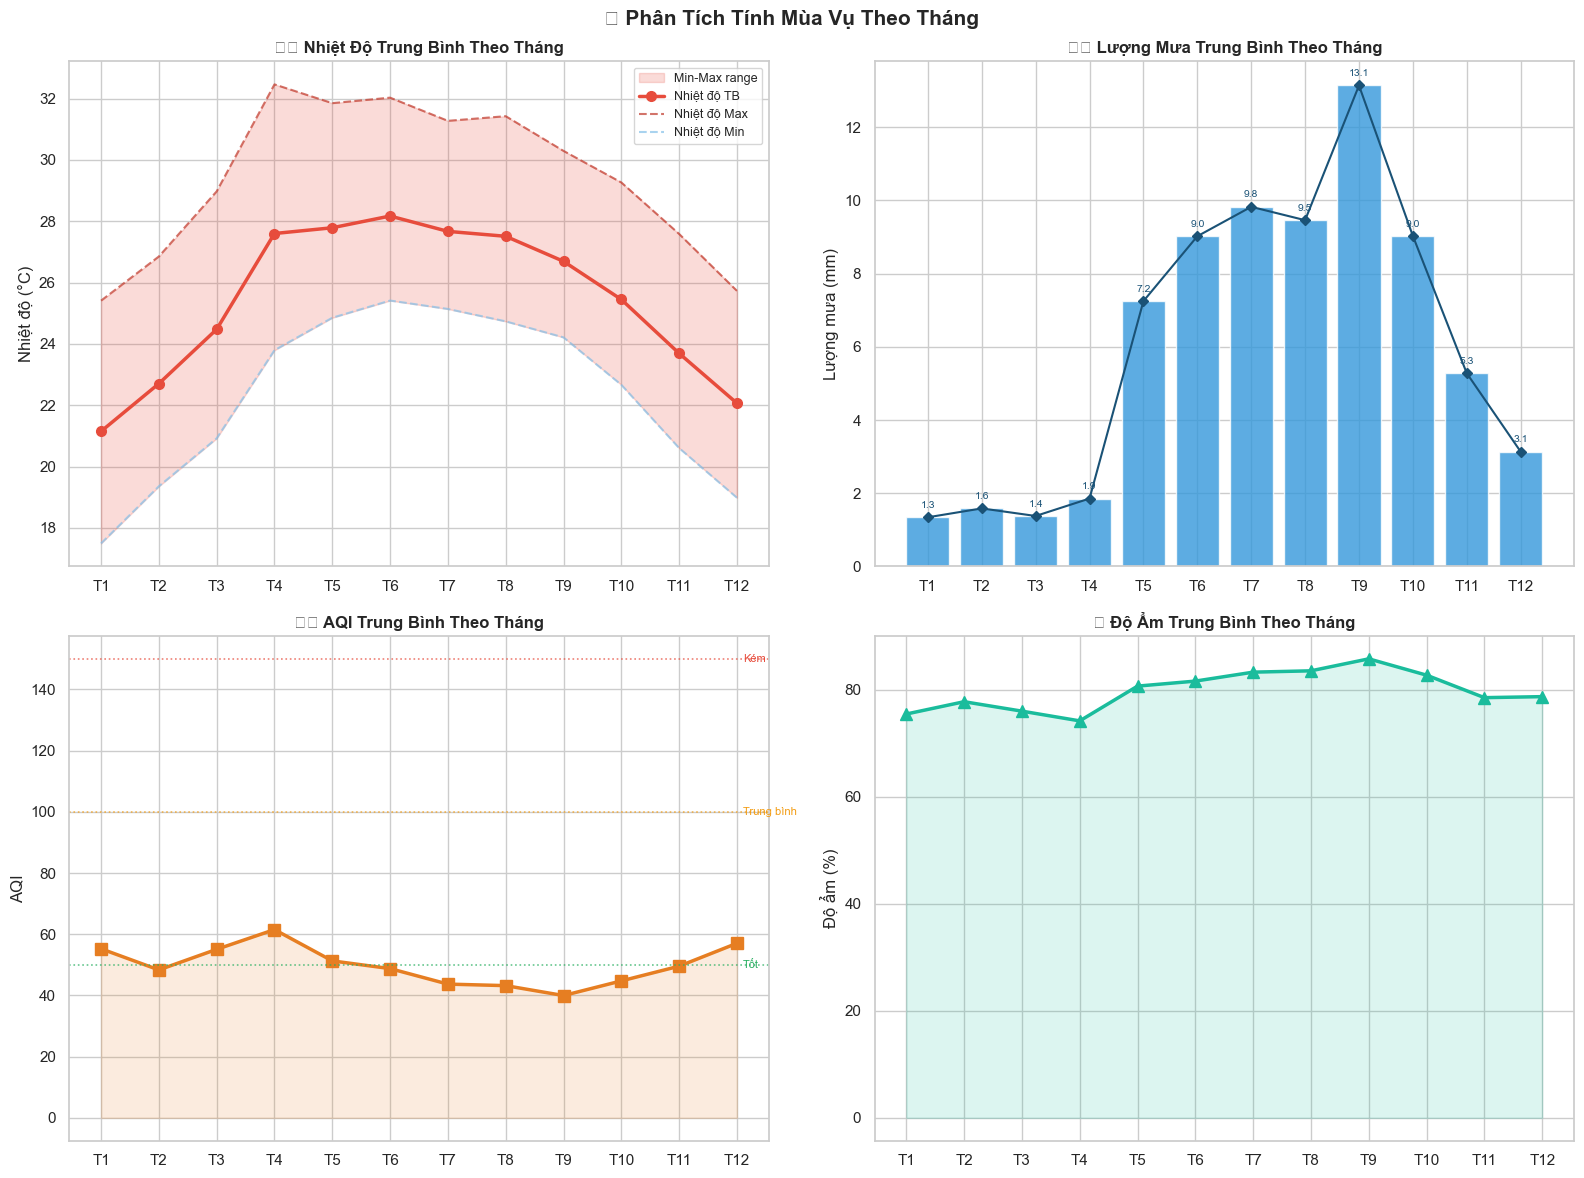

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Nhiệt độ
ax = axes[0, 0]
ax.fill_between(monthly['month'], monthly['temp_min'], monthly['temp_max'], alpha=0.2, color='#e74c3c', label='Min-Max range')
ax.plot(monthly['month'], monthly['temp_mean'], color='#e74c3c', marker='o', linewidth=2.5, markersize=7, label='Nhiệt độ TB')
ax.plot(monthly['month'], monthly['temp_max'], color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.7, label='Nhiệt độ Max')
ax.plot(monthly['month'], monthly['temp_min'], color='#85c1e9', linestyle='--', linewidth=1.5, alpha=0.7, label='Nhiệt độ Min')
ax.set_title('🌡️ Nhiệt Độ Trung Bình Theo Tháng', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(months_label)
ax.set_ylabel('Nhiệt độ (°C)'); ax.legend(fontsize=9)

# Lượng mưa
ax = axes[0, 1]
bars = ax.bar(monthly['month'], monthly['rain'], color='#3498db', alpha=0.8, edgecolor='white')
ax.plot(monthly['month'], monthly['rain'], color='#1a5276', marker='D', linewidth=1.5, markersize=5)
ax.set_title('🌧️ Lượng Mưa Trung Bình Theo Tháng', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(months_label)
ax.set_ylabel('Lượng mưa (mm)')
for bar, val in zip(bars, monthly['rain']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}',
            ha='center', va='bottom', fontsize=7.5, color='#1a5276')

# AQI
ax = axes[1, 0]
ax.plot(monthly['month'], monthly['aqi'], color='#e67e22', marker='s', linewidth=2.5, markersize=8)
ax.fill_between(monthly['month'], monthly['aqi'], alpha=0.15, color='#e67e22')
for thresh, lbl, clr in [(50,'Tốt','#27ae60'),(100,'Trung bình','#f39c12'),(150,'Kém','#e74c3c')]:
    ax.axhline(thresh, color=clr, linestyle=':', alpha=0.7, linewidth=1.2)
    ax.text(12.1, thresh, lbl, color=clr, va='center', fontsize=8)
ax.set_title('🌫️ AQI Trung Bình Theo Tháng', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(months_label)
ax.set_ylabel('AQI')

# Độ ẩm
ax = axes[1, 1]
ax.plot(monthly['month'], monthly['humidity'], color='#1abc9c', marker='^', linewidth=2.5, markersize=8)
ax.fill_between(monthly['month'], monthly['humidity'], alpha=0.15, color='#1abc9c')
ax.set_title('💧 Độ Ẩm Trung Bình Theo Tháng', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(months_label)
ax.set_ylabel('Độ ẩm (%)')

plt.suptitle('📅 Phân Tích Tính Mùa Vụ Theo Tháng', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

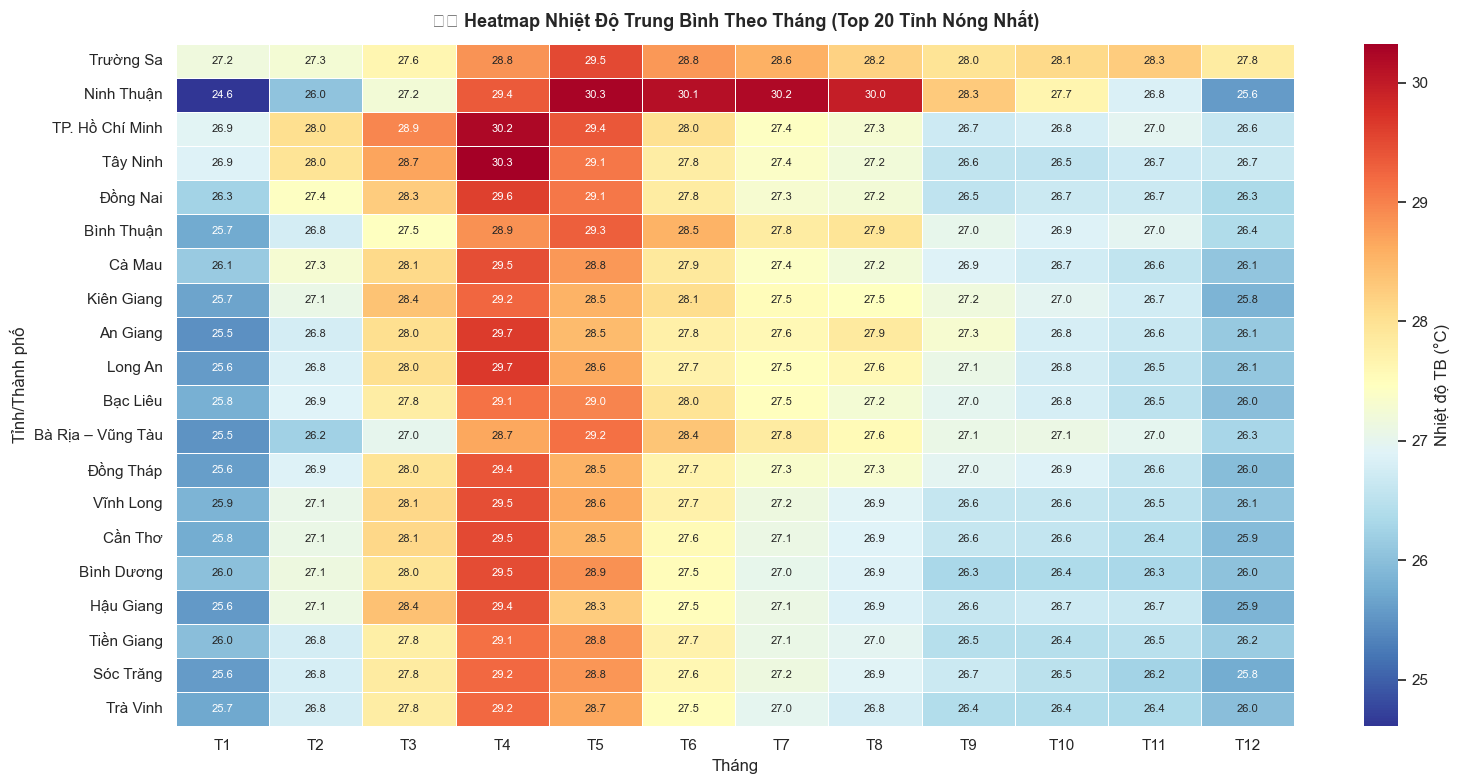

In [17]:
# Heatmap nhiệt độ theo tỉnh x tháng (Top 20 tỉnh nóng nhất)
heat_data = df.groupby(['province', 'month'])['temperature_mean'].mean().unstack()
top20 = df.groupby('province')['temperature_mean'].mean().nlargest(20).index
heat_data_top = heat_data.loc[top20]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(heat_data_top, cmap='RdYlBu_r', annot=True, fmt='.1f',
            annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'label': 'Nhiệt độ TB (°C)'},
            xticklabels=months_label, ax=ax)
ax.set_title('🌡️ Heatmap Nhiệt Độ Trung Bình Theo Tháng (Top 20 Tỉnh Nóng Nhất)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Tháng'); ax.set_ylabel('Tỉnh/Thành phố')
plt.tight_layout()
plt.show()

---

## 6. 🏙️ Phân Tích Theo Tỉnh/Thành Phố


In [18]:
province_stats = df.groupby('province').agg(
    temp_mean=('temperature_mean', 'mean'),
    temp_std=('temperature_mean', 'std'),
    rain_total=('rain_sum', 'sum'),
    rain_mean=('rain_sum', 'mean'),
    aqi_mean=('aqi', 'mean'),
    humidity_mean=('humidity_mean', 'mean'),
    wind_mean=('wind_speed_max', 'mean'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
).reset_index()

print(f'📊 Dữ liệu tổng hợp cho {len(province_stats)} tỉnh/thành')
province_stats.head()

📊 Dữ liệu tổng hợp cho 63 tỉnh/thành


,province,temp_mean,temp_std,rain_total,rain_mean,aqi_mean,humidity_mean,wind_mean,latitude,longitude
0,An Giang,27.435326,1.595480,5110.7,5.454322,49.626467,78.960512,14.938847,10.5185,105.1152
1,Bà Rịa – Vũng Tàu,27.363248,1.336175,3953.8,4.224145,37.423077,80.554487,20.489530,10.4114,107.1362
2,Bình Dương,27.284244,1.454340,5668.9,6.075991,51.314041,78.500536,15.167310,11.0531,106.6661
3,Bình Phước,26.768917,1.564664,6800.9,7.289282,40.857449,77.953912,14.057235,11.7516,106.8778
4,Bình Thuận,27.547103,1.414549,3329.3,3.572210,35.812232,75.415236,22.952575,10.9333,108.1000


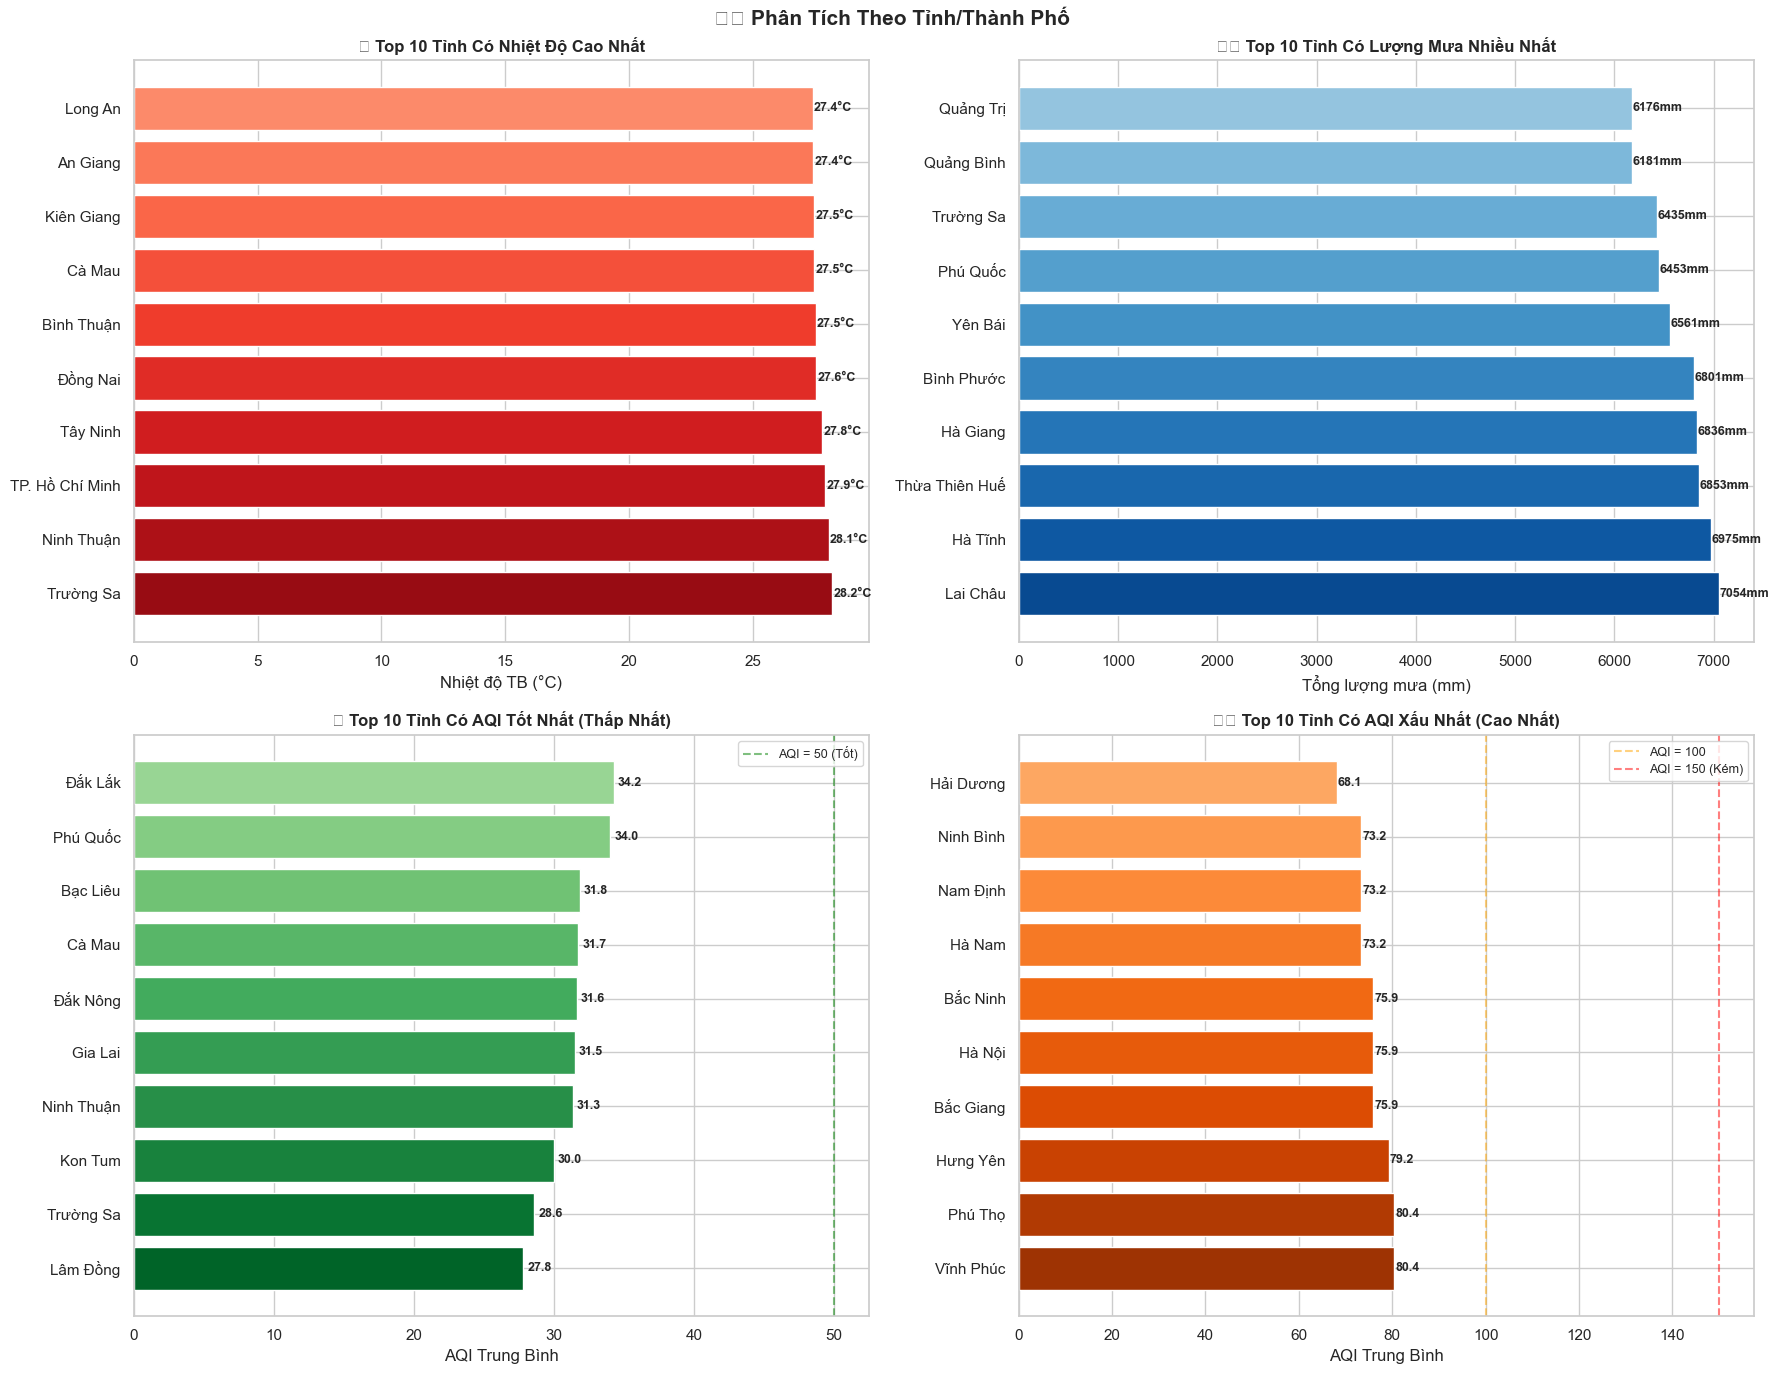

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 10 nóng nhất
ax = axes[0, 0]
top_hot = province_stats.nlargest(10, 'temp_mean')
colors_hot = plt.cm.Reds(np.linspace(0.4, 0.9, 10))[::-1]
bars = ax.barh(top_hot['province'], top_hot['temp_mean'], color=colors_hot, edgecolor='white')
ax.set_title('🔥 Top 10 Tỉnh Có Nhiệt Độ Cao Nhất', fontsize=12, fontweight='bold')
ax.set_xlabel('Nhiệt độ TB (°C)')
for bar, val in zip(bars, top_hot['temp_mean']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}°C', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(right=top_hot['temp_mean'].max() + 1.5)

# Top 10 mưa nhiều nhất
ax = axes[0, 1]
top_rain = province_stats.nlargest(10, 'rain_total')
colors_rain = plt.cm.Blues(np.linspace(0.4, 0.9, 10))[::-1]
bars = ax.barh(top_rain['province'], top_rain['rain_total'], color=colors_rain, edgecolor='white')
ax.set_title('🌧️ Top 10 Tỉnh Có Lượng Mưa Nhiều Nhất', fontsize=12, fontweight='bold')
ax.set_xlabel('Tổng lượng mưa (mm)')
for bar, val in zip(bars, top_rain['rain_total']):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}mm', va='center', fontsize=9, fontweight='bold')

# AQI tốt nhất
ax = axes[1, 0]
top_aqi_good = province_stats.nsmallest(10, 'aqi_mean')
colors_green = plt.cm.Greens(np.linspace(0.4, 0.9, 10))[::-1]
bars = ax.barh(top_aqi_good['province'], top_aqi_good['aqi_mean'], color=colors_green, edgecolor='white')
ax.set_title('✅ Top 10 Tỉnh Có AQI Tốt Nhất (Thấp Nhất)', fontsize=12, fontweight='bold')
ax.set_xlabel('AQI Trung Bình')
ax.axvline(50, color='green', linestyle='--', alpha=0.5, label='AQI = 50 (Tốt)')
ax.legend(fontsize=9)
for bar, val in zip(bars, top_aqi_good['aqi_mean']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

# AQI xấu nhất
ax = axes[1, 1]
top_aqi_bad = province_stats.nlargest(10, 'aqi_mean')
colors_orange = plt.cm.Oranges(np.linspace(0.4, 0.9, 10))[::-1]
bars = ax.barh(top_aqi_bad['province'], top_aqi_bad['aqi_mean'], color=colors_orange, edgecolor='white')
ax.set_title('⚠️ Top 10 Tỉnh Có AQI Xấu Nhất (Cao Nhất)', fontsize=12, fontweight='bold')
ax.set_xlabel('AQI Trung Bình')
ax.axvline(100, color='orange', linestyle='--', alpha=0.5, label='AQI = 100')
ax.axvline(150, color='red', linestyle='--', alpha=0.5, label='AQI = 150 (Kém)')
ax.legend(fontsize=9)
for bar, val in zip(bars, top_aqi_bad['aqi_mean']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('🏙️ Phân Tích Theo Tỉnh/Thành Phố', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

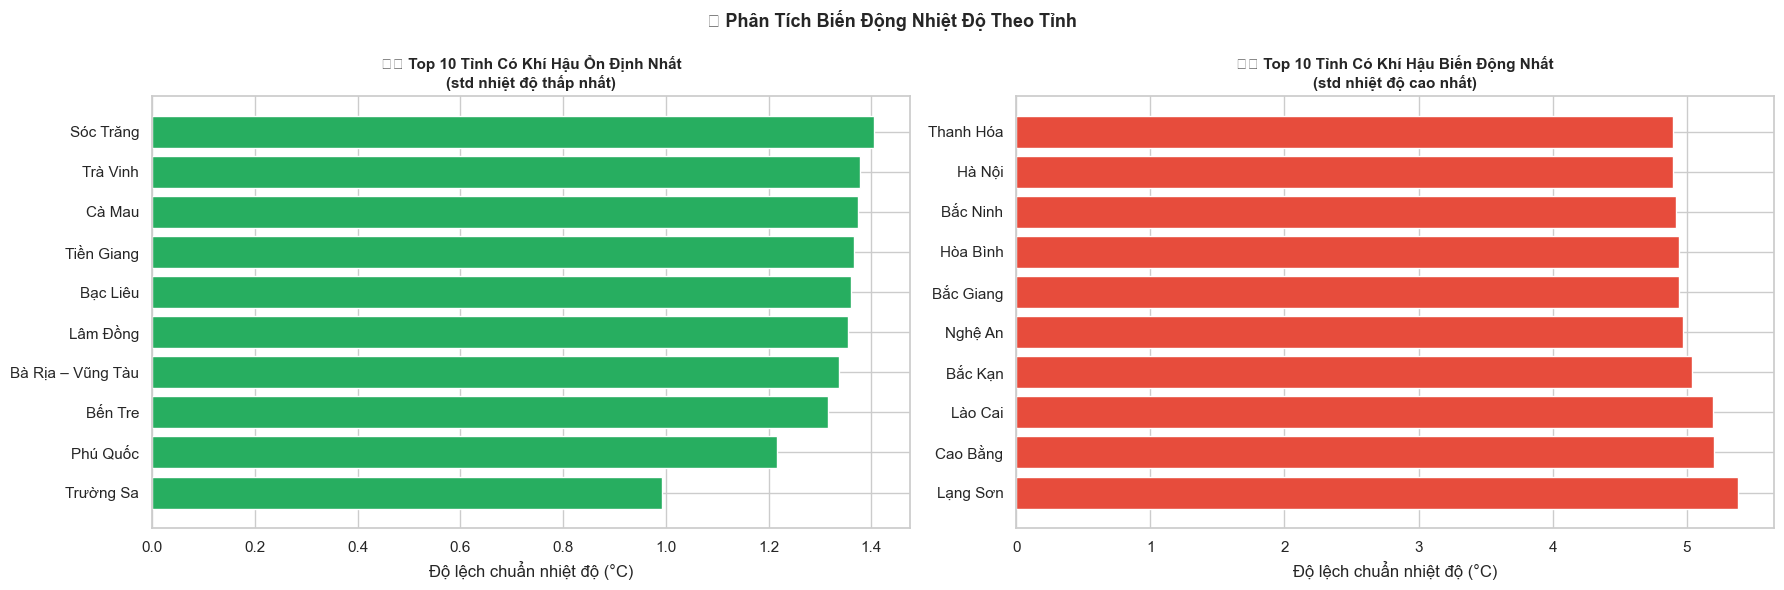

In [20]:
# Biến động nhiệt độ theo tỉnh
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

stable = province_stats.nsmallest(10, 'temp_std')
axes[0].barh(stable['province'], stable['temp_std'], color='#27ae60', edgecolor='white')
axes[0].set_title('🌤️ Top 10 Tỉnh Có Khí Hậu Ổn Định Nhất\n(std nhiệt độ thấp nhất)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Độ lệch chuẩn nhiệt độ (°C)')

volatile = province_stats.nlargest(10, 'temp_std')
axes[1].barh(volatile['province'], volatile['temp_std'], color='#e74c3c', edgecolor='white')
axes[1].set_title('🌪️ Top 10 Tỉnh Có Khí Hậu Biến Động Nhất\n(std nhiệt độ cao nhất)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Độ lệch chuẩn nhiệt độ (°C)')

plt.suptitle('📊 Phân Tích Biến Động Nhiệt Độ Theo Tỉnh', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 7. 🔗 Quan Hệ Giữa Các Biến (Bivariate Analysis)


### 7.1 Correlation Matrix

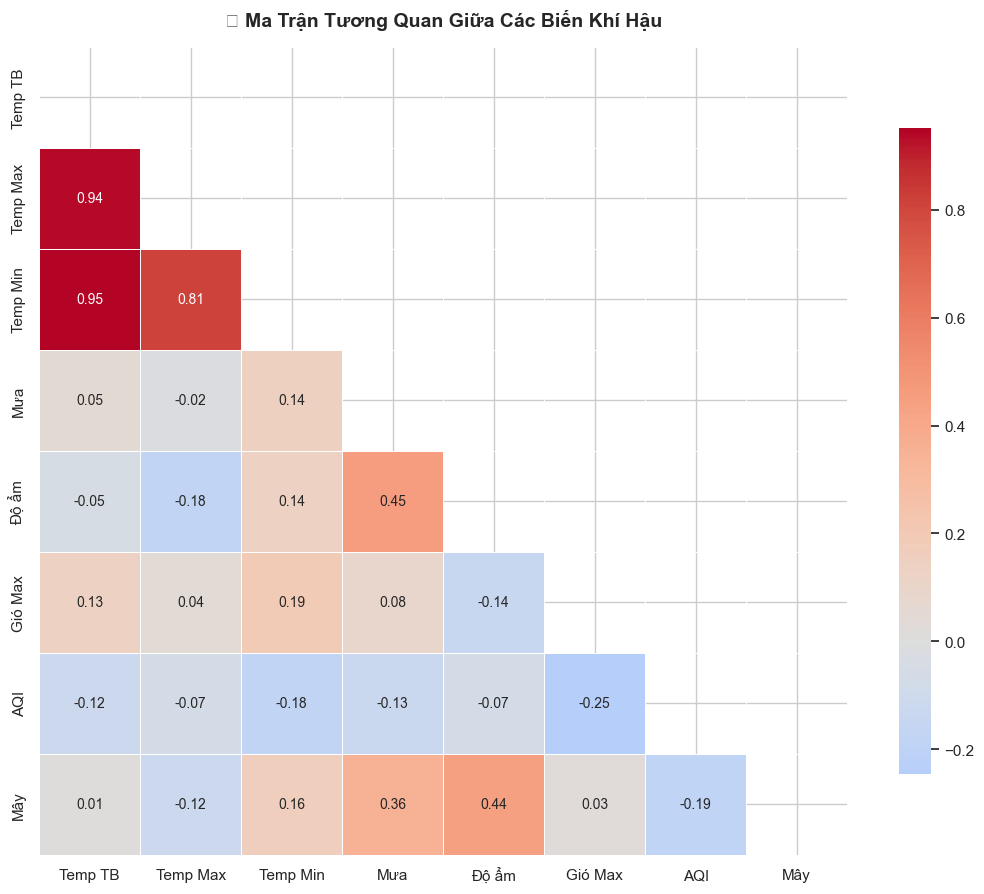

In [21]:
corr_cols = ['temperature_mean','temperature_max','temperature_min',
             'rain_sum','humidity_mean','wind_speed_max','aqi','cloud_cover_mean']
corr_matrix = df[corr_cols].corr()

rename_map = {
    'temperature_mean':'Temp TB','temperature_max':'Temp Max','temperature_min':'Temp Min',
    'rain_sum':'Mưa','humidity_mean':'Độ ẩm','wind_speed_max':'Gió Max',
    'aqi':'AQI','cloud_cover_mean':'Mây'
}
corr_display = corr_matrix.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_display, dtype=bool))
sns.heatmap(corr_display, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 10},
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('🔗 Ma Trận Tương Quan Giữa Các Biến Khí Hậu', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [22]:
# Top cặp tương quan mạnh
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Biến 1', 'Biến 2', 'Hệ số tương quan']
corr_pairs = corr_pairs[
    (corr_pairs['Biến 1'] != corr_pairs['Biến 2']) &
    (corr_pairs['Biến 1'] < corr_pairs['Biến 2'])
].sort_values('Hệ số tương quan', key=abs, ascending=False)

print('🔝 Top 10 cặp biến tương quan mạnh nhất:')
corr_pairs.head(10).style.background_gradient(cmap='RdBu_r', subset=['Hệ số tương quan']).format({'Hệ số tương quan': '{:.3f}'})

🔝 Top 10 cặp biến tương quan mạnh nhất:


,Biến 1,Biến 2,Hệ số tương quan
2,temperature_mean,temperature_min,0.952
8,temperature_max,temperature_mean,0.941
10,temperature_max,temperature_min,0.815
35,humidity_mean,rain_sum,0.454
60,cloud_cover_mean,humidity_mean,0.440
59,cloud_cover_mean,rain_sum,0.357
53,aqi,wind_speed_max,-0.246
21,temperature_min,wind_speed_max,0.194
55,aqi,cloud_cover_mean,-0.186
33,humidity_mean,temperature_max,-0.185


### 7.2 Scatter Plots

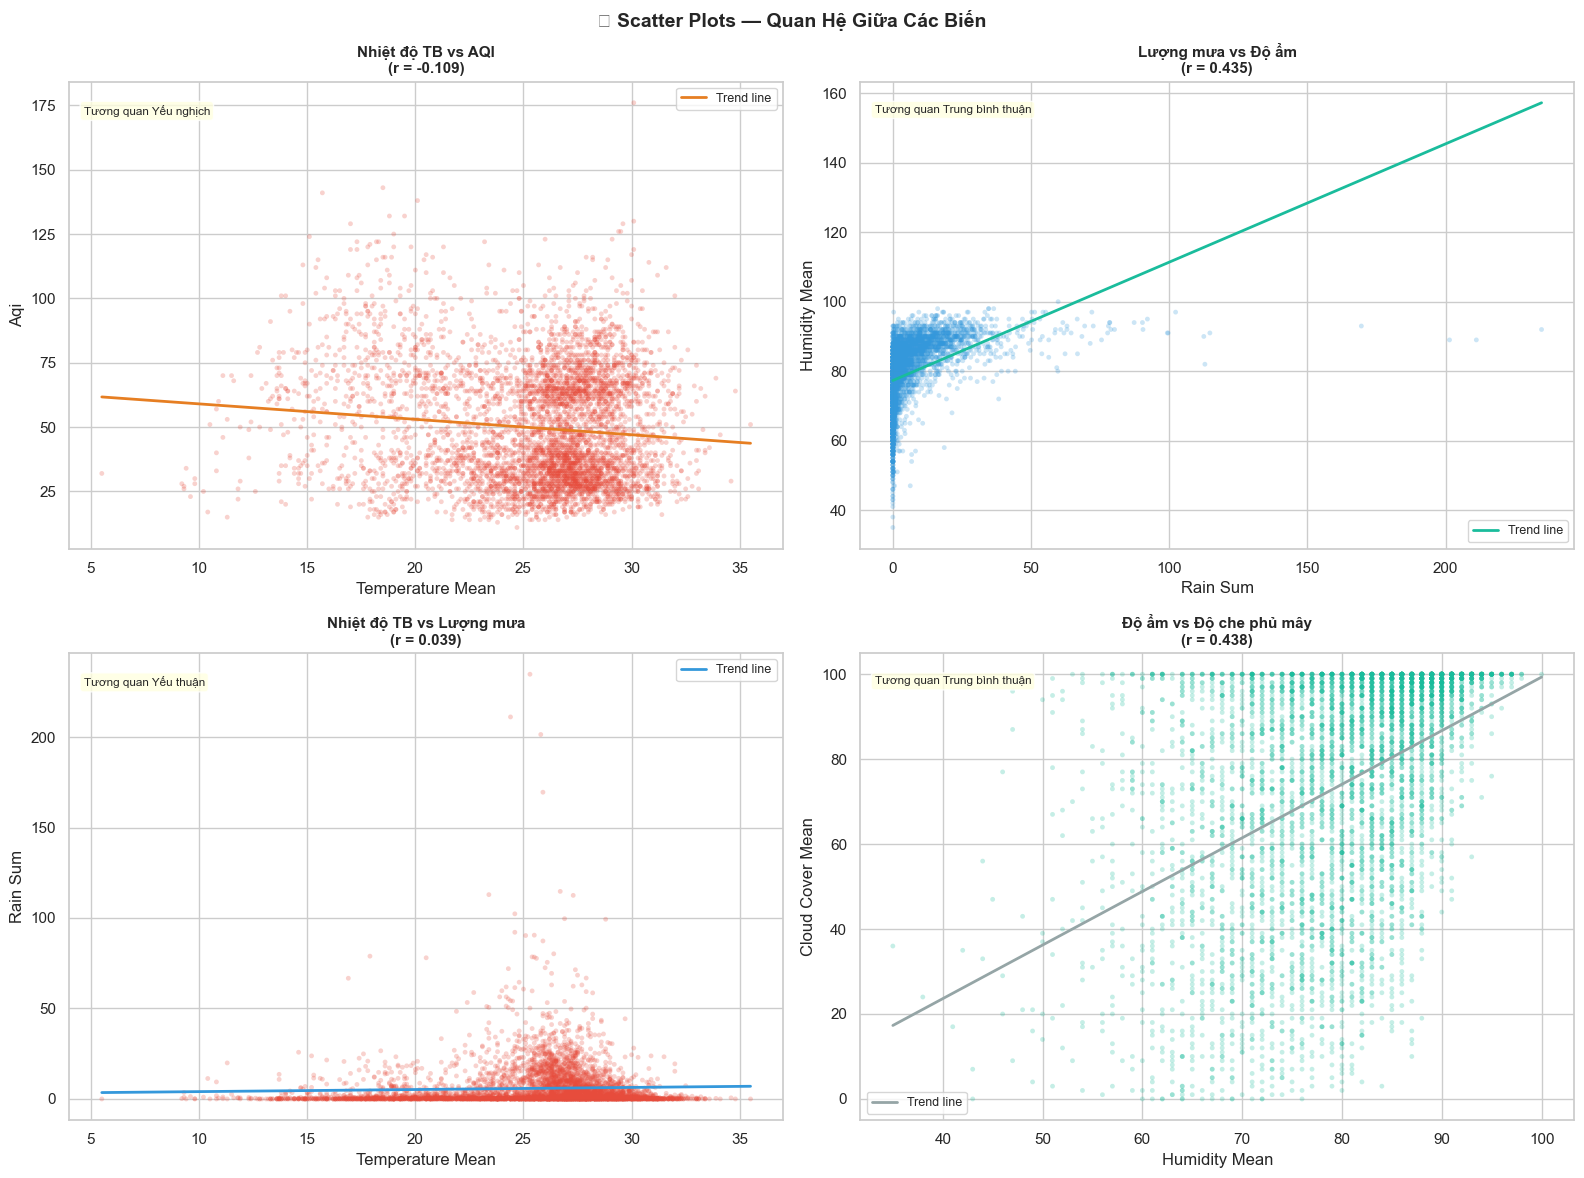

In [23]:
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

scatter_pairs = [
    ('temperature_mean', 'aqi',           'Nhiệt độ TB vs AQI',          '#e74c3c', '#e67e22'),
    ('rain_sum',         'humidity_mean', 'Lượng mưa vs Độ ẩm',          '#3498db', '#1abc9c'),
    ('temperature_mean', 'rain_sum',      'Nhiệt độ TB vs Lượng mưa',    '#e74c3c', '#3498db'),
    ('humidity_mean',    'cloud_cover_mean','Độ ẩm vs Độ che phủ mây',   '#1abc9c', '#95a5a6'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (x, y, title, cx, cy) in zip(axes.flat, scatter_pairs):
    valid = sample_df[[x, y]].dropna()
    r = valid[x].corr(valid[y])
    ax.scatter(valid[x], valid[y], alpha=0.25, s=12, c=cx, edgecolors='none')
    z = np.polyfit(valid[x], valid[y], 1)
    x_line = np.linspace(valid[x].min(), valid[x].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color=cy, linewidth=2, label='Trend line')
    ax.set_title(f'{title}\n(r = {r:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(x.replace('_', ' ').title())
    ax.set_ylabel(y.replace('_', ' ').title())
    ax.legend(fontsize=9)
    strength = 'Mạnh' if abs(r) > 0.6 else ('Trung bình' if abs(r) > 0.3 else 'Yếu')
    direction = 'thuận' if r > 0 else 'nghịch'
    ax.text(0.02, 0.95, f'Tương quan {strength} {direction}',
            transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('🔗 Scatter Plots — Quan Hệ Giữa Các Biến', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

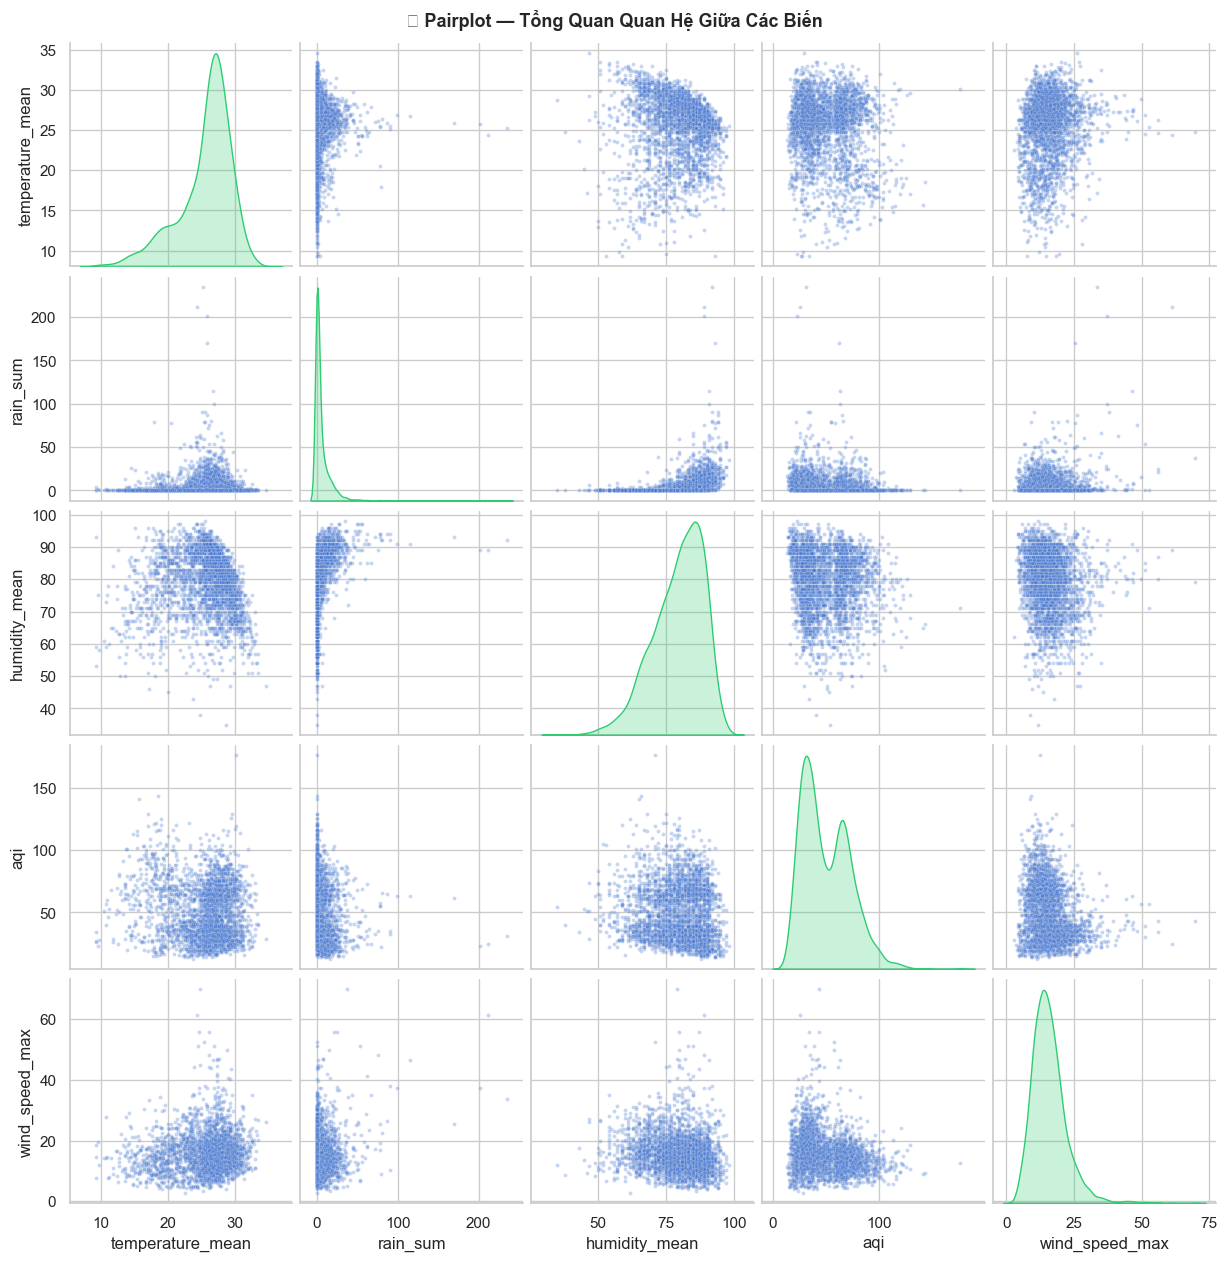

In [24]:
# Pairplot
pair_cols = ['temperature_mean', 'rain_sum', 'humidity_mean', 'aqi', 'wind_speed_max']
pair_sample = df[pair_cols].dropna().sample(n=min(3000, len(df)), random_state=42)

g = sns.pairplot(pair_sample, diag_kind='kde',
                 plot_kws={'alpha': 0.3, 's': 8},
                 diag_kws={'color': '#2ecc71', 'fill': True})
g.figure.suptitle('📊 Pairplot — Tổng Quan Quan Hệ Giữa Các Biến', fontsize=13, fontweight='bold', y=1.01)
plt.show()

---

## 8. 🗺️ Phân Bố Địa Lý


In [25]:
def classify_region(lat):
    if lat >= 20: return 'Miền Bắc'
    elif lat >= 14: return 'Miền Trung'
    else: return 'Miền Nam'

province_stats['region'] = province_stats['latitude'].apply(classify_region)
df_geo = df.merge(province_stats[['province', 'region']], on='province', how='left')
region_colors = {'Miền Bắc': '#3498db', 'Miền Trung': '#e67e22', 'Miền Nam': '#e74c3c'}

print('Phân bố theo vùng:')
print(province_stats['region'].value_counts())

Phân bố theo vùng:
region
Miền Nam      30
Miền Bắc      24
Miền Trung     9
Name: count, dtype: int64


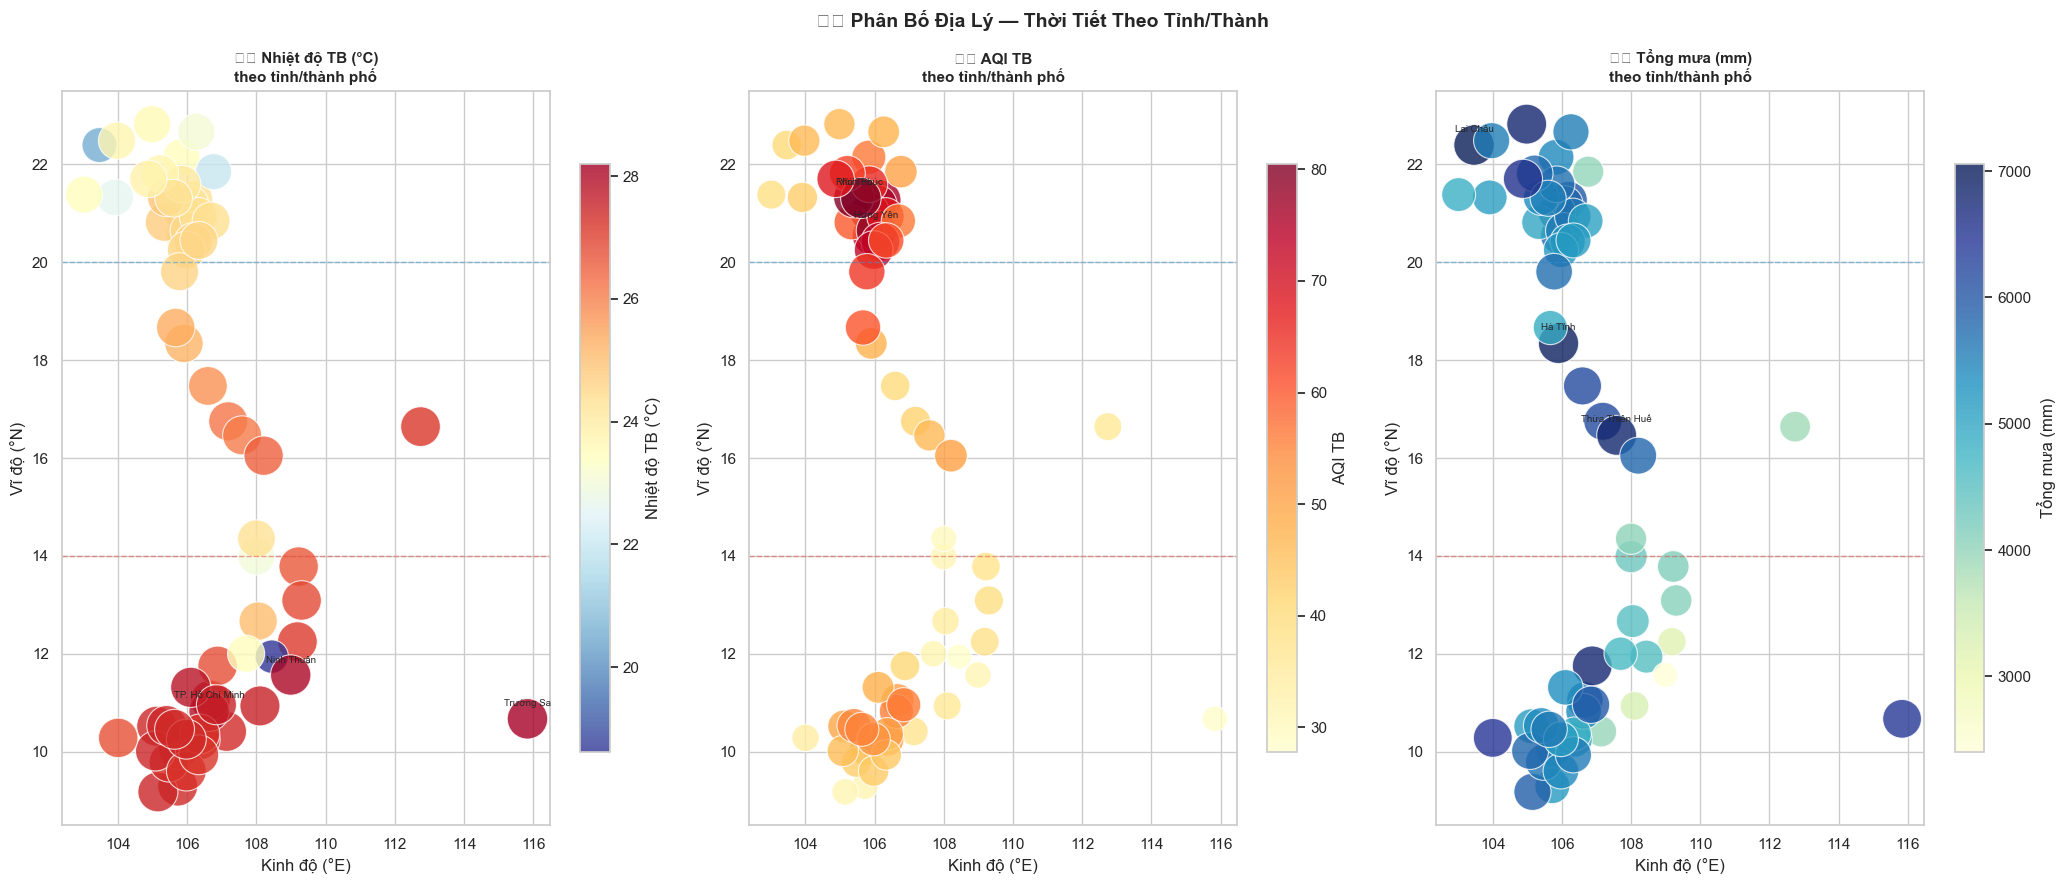

In [26]:
# Bubble Map
fig, axes = plt.subplots(1, 3, figsize=(21, 9))

metrics = [
    ('temp_mean',  'Nhiệt độ TB (°C)', 'RdYlBu_r', axes[0]),
    ('aqi_mean',   'AQI TB',           'YlOrRd',   axes[1]),
    ('rain_total', 'Tổng mưa (mm)',    'YlGnBu',   axes[2]),
]

for col, label, cmap, ax in metrics:
    sc = ax.scatter(
        province_stats['longitude'], province_stats['latitude'],
        c=province_stats[col],
        s=province_stats[col] / province_stats[col].max() * 800 + 50,
        cmap=cmap, alpha=0.8, edgecolors='white', linewidth=0.8
    )
    plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    ax.set_xlabel('Kinh độ (°E)'); ax.set_ylabel('Vĩ độ (°N)')
    ax.set_title(f'🗺️ {label}\ntheo tỉnh/thành phố', fontsize=11, fontweight='bold')
    ax.axhline(20, color='#3498db', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(14, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1)
    top3 = province_stats.nlargest(3, col)
    for _, row in top3.iterrows():
        ax.annotate(row['province'], (row['longitude'], row['latitude']),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')

plt.suptitle('🗺️ Phân Bố Địa Lý — Thời Tiết Theo Tỉnh/Thành', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

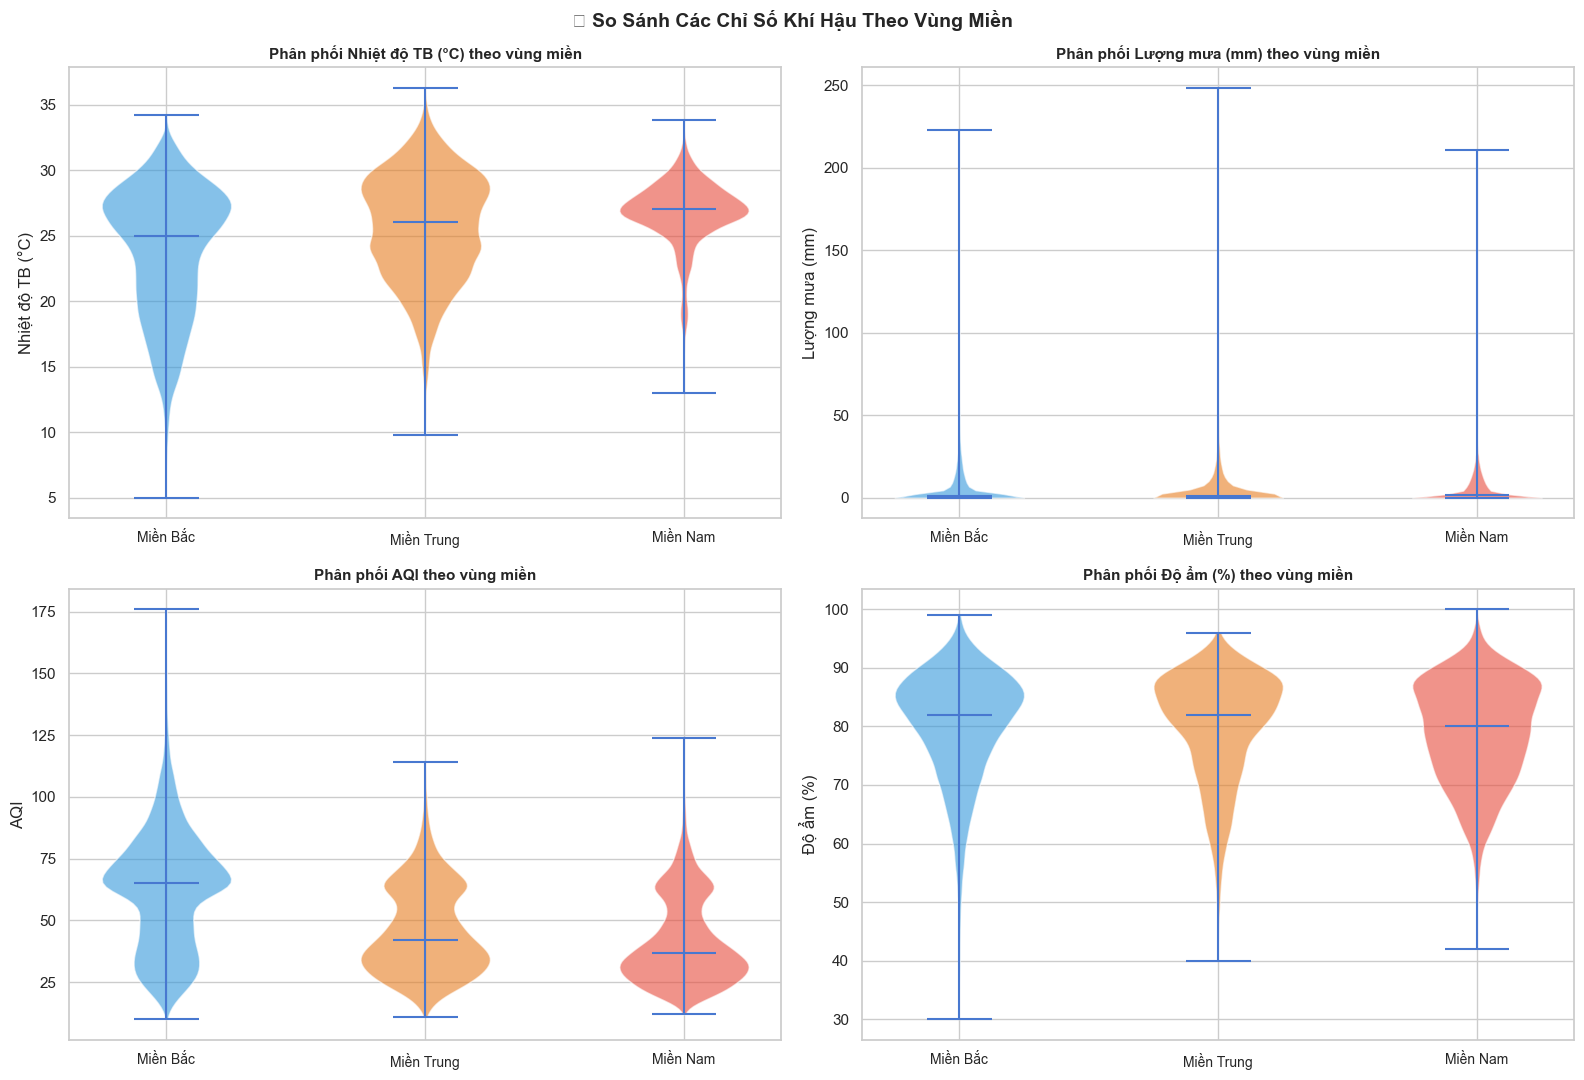

In [27]:
# Violin Plot so sánh vùng miền
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

region_metrics = [
    ('temperature_mean', 'Nhiệt độ TB (°C)', axes[0,0]),
    ('rain_sum',         'Lượng mưa (mm)',   axes[0,1]),
    ('aqi',              'AQI',              axes[1,0]),
    ('humidity_mean',    'Độ ẩm (%)',        axes[1,1]),
]

for col, label, ax in region_metrics:
    data_by_region = [
        df_geo[df_geo['region'] == r][col].dropna().values
        for r in ['Miền Bắc', 'Miền Trung', 'Miền Nam']
    ]
    colors_v = [region_colors[r] for r in ['Miền Bắc', 'Miền Trung', 'Miền Nam']]
    vp = ax.violinplot(data_by_region, positions=[1,2,3], showmedians=True)
    for patch, color in zip(vp['bodies'], colors_v):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f'Phân phối {label} theo vùng miền', fontsize=11, fontweight='bold')
    ax.set_xticks([1,2,3])
    ax.set_xticklabels(['Miền Bắc', 'Miền Trung', 'Miền Nam'], fontsize=10)
    ax.set_ylabel(label)

plt.suptitle('📊 So Sánh Các Chỉ Số Khí Hậu Theo Vùng Miền', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 9. 💡 Insights Chính


In [28]:
# Tính toán số liệu cho insights
region_temp_std   = df_geo.groupby('region')['temperature_mean'].std()
rain_peak         = monthly.loc[monthly['rain'].idxmax(), 'month']
rain_season_sum   = monthly[monthly['month'].between(5, 10)]['rain'].sum()
rain_total_sum    = monthly['rain'].sum()
aqi_temp_corr     = df[['temperature_mean', 'aqi']].corr().iloc[0, 1]
humidity_corr_rain= df[['rain_sum', 'humidity_mean']].corr().iloc[0, 1]
mb_std = region_temp_std.get('Miền Bắc', 0)
mn_std = region_temp_std.get('Miền Nam', 0)

print('=' * 65)
print('                  💡 INSIGHTS CHÍNH')
print('=' * 65)

print(f'\n1. 🌡️  NHIỆT ĐỘ & VÙNG MIỀN')
print(f'   • Miền Nam ổn định hơn Miền Bắc: std = {mn_std:.2f}°C vs {mb_std:.2f}°C')
print(f'   • Miền Bắc có mùa Đông lạnh rõ rệt (T1-T2), Miền Nam nóng quanh năm')

print(f'\n2. 🌧️  TÍNH MÙA VỤ CỦA LƯỢNG MƯA')
print(f'   • Mùa mưa T5-T10 chiếm ~{rain_season_sum/rain_total_sum*100:.0f}% tổng lượng mưa cả năm')
print(f'   • Đỉnh mưa vào tháng {rain_peak}')

print(f'\n3. 🌫️  CHẤT LƯỢNG KHÔNG KHÍ')
print(f'   • Tương quan AQI-Nhiệt độ: r = {aqi_temp_corr:.3f} (yếu)')
top_aqi_prov = province_stats.nlargest(3, 'aqi_mean')[['province','aqi_mean']]
for _, row in top_aqi_prov.iterrows():
    print(f'   • AQI xấu: {row["province"]} ({row["aqi_mean"]:.1f})')

print(f'\n4. 💧 ĐỘ ẨM & LƯỢNG MƯA')
print(f'   • Tương quan độ ẩm-lượng mưa: r = {humidity_corr_rain:.3f}')
high_humid = province_stats.nlargest(3, 'humidity_mean')['province'].tolist()
print(f'   • Độ ẩm cao nhất: {", ".join(high_humid)}')

print(f'\n5. 🌡️  KHÍ HẬU ỔN ĐỊNH vs BIẾN ĐỘNG')
stable_prov = province_stats.nsmallest(3, 'temp_std')['province'].tolist()
volatile_prov = province_stats.nlargest(3, 'temp_std')['province'].tolist()
print(f'   • Ổn định nhất: {", ".join(stable_prov)}')
print(f'   • Biến động nhất: {", ".join(volatile_prov)}')

print(f'\n6. 🌧️  LƯỢNG MƯA THEO VÙNG')
top_rain_prov = province_stats.nlargest(5, 'rain_total')['province'].tolist()
print(f'   • Mưa nhiều nhất: {", ".join(top_rain_prov)}')
print(f'   • Miền Trung chịu mưa lớn từ bão/áp thấp nhiệt đới (T9-T12)')

print(f'\n7. 🌡️  TỈNH NÓNG NHẤT')
top_hot_prov = province_stats.nlargest(3, 'temp_mean')[['province','temp_mean']]
for _, row in top_hot_prov.iterrows():
    print(f'   • {row["province"]}: {row["temp_mean"]:.1f}°C TB')

print('\n' + '=' * 65)

                  💡 INSIGHTS CHÍNH

1. 🌡️  NHIỆT ĐỘ & VÙNG MIỀN
   • Miền Nam ổn định hơn Miền Bắc: std = 2.55°C vs 4.90°C
   • Miền Bắc có mùa Đông lạnh rõ rệt (T1-T2), Miền Nam nóng quanh năm

2. 🌧️  TÍNH MÙA VỤ CỦA LƯỢNG MƯA
   • Mùa mưa T5-T10 chiếm ~80% tổng lượng mưa cả năm
   • Đỉnh mưa vào tháng 9

3. 🌫️  CHẤT LƯỢNG KHÔNG KHÍ
   • Tương quan AQI-Nhiệt độ: r = -0.124 (yếu)
   • AQI xấu: Vĩnh Phúc (80.4)
   • AQI xấu: Phú Thọ (80.4)
   • AQI xấu: Hưng Yên (79.2)

4. 💧 ĐỘ ẨM & LƯỢNG MƯA
   • Tương quan độ ẩm-lượng mưa: r = 0.454
   • Độ ẩm cao nhất: Hòa Bình, Yên Bái, Bến Tre

5. 🌡️  KHÍ HẬU ỔN ĐỊNH vs BIẾN ĐỘNG
   • Ổn định nhất: Trường Sa, Phú Quốc, Bến Tre
   • Biến động nhất: Lạng Sơn, Cao Bằng, Lào Cai

6. 🌧️  LƯỢNG MƯA THEO VÙNG
   • Mưa nhiều nhất: Lai Châu, Hà Tĩnh, Thừa Thiên Huế, Hà Giang, Bình Phước
   • Miền Trung chịu mưa lớn từ bão/áp thấp nhiệt đới (T9-T12)

7. 🌡️  TỈNH NÓNG NHẤT
   • Trường Sa: 28.2°C TB
   • Ninh Thuận: 28.1°C TB
   • TP. Hồ Chí Minh: 27.9°C TB



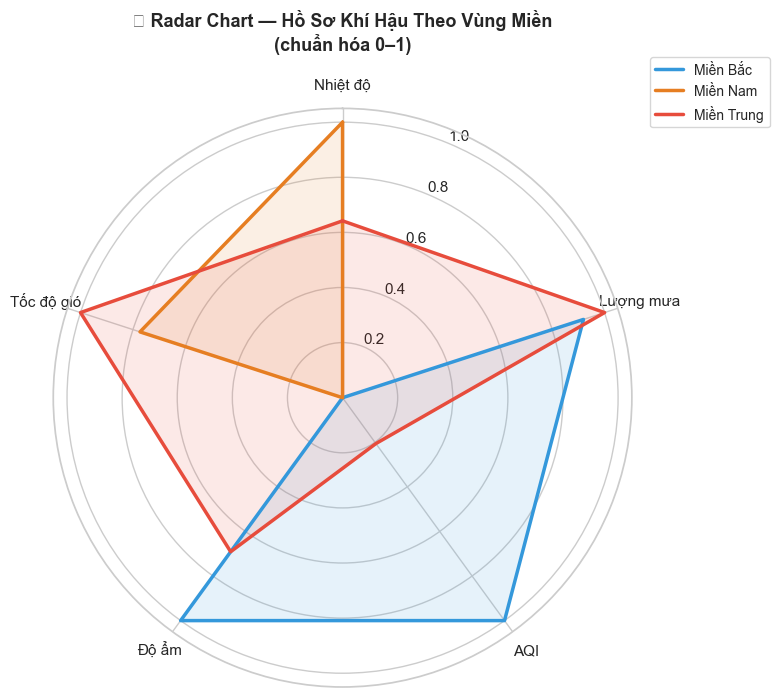

In [29]:
# Radar Chart - Hồ sơ khí hậu 3 vùng
radar_metrics = ['temp_mean', 'rain_total', 'aqi_mean', 'humidity_mean', 'wind_mean']
radar_labels  = ['Nhiệt độ', 'Lượng mưa', 'AQI', 'Độ ẩm', 'Tốc độ gió']

region_radar = province_stats.groupby('region')[radar_metrics].mean()
region_radar_norm = (region_radar - region_radar.min()) / (region_radar.max() - region_radar.min())

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=11)

colors = ['#3498db', '#e67e22', '#e74c3c']
for (region_name, row), color in zip(region_radar_norm.iterrows(), colors):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=2.5, label=region_name)
    ax.fill(angles, vals, color=color, alpha=0.12)

ax.set_title('🌐 Radar Chart — Hồ Sơ Khí Hậu Theo Vùng Miền\n(chuẩn hóa 0–1)',
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

---

## 10. 📐 Ảnh Hưởng EDA Đến Thiết Kế Dashboard


Dựa trên kết quả EDA, bảng mapping từ insight → quyết định thiết kế:

| # | Phát hiện từ EDA | Quyết định thiết kế Dashboard |
|---|-----------------|--------------------------------|
| 1 | **Dữ liệu có tính mùa vụ** (mưa T5–T10, nhiệt độ biến đổi theo tháng) | ➡️ Thêm **Line Chart theo tháng**; bộ lọc quý/tháng |
| 2 | **Chênh lệch lớn giữa các tỉnh** (AQI, mưa, nhiệt độ) | ➡️ Thêm **Bản đồ Choropleth** và **Bubble Map** |
| 3 | **AQI và nhiệt độ ít tương quan** | ➡️ **Không đặt AQI và nhiệt độ cạnh nhau** |
| 4 | **Nhiều chỉ số khí hậu** cần so sánh đồng thời | ➡️ Dùng **Radar Chart** so sánh hồ sơ khí hậu |
| 5 | **Miền Nam ổn định, Miền Bắc biến động** | ➡️ Thêm tab **So sánh vùng miền**; violin plot |
| 6 | **Lượng mưa phân phối lệch phải** (skewness cao) | ➡️ Dùng **thang log** hoặc bin khi hiển thị mưa |
| 7 | **Độ ẩm tương quan với lượng mưa** | ➡️ Hiển thị cùng panel; dual-axis chart |
| 8 | **AQI cao vào mùa khô** (T1–4, T11–12) | ➡️ Thêm **cảnh báo AQI theo mùa** (badge màu) |
| 9 | **Top tỉnh nóng/mưa/AQI** khác nhau hoàn toàn | ➡️ Thêm **Ranking widget** riêng cho từng chỉ số |
| 10 | **Miền Trung mưa lớn T9–T12** do bão | ➡️ Thêm **chú thích sự kiện** trên timeline; highlight mùa bão |


In [30]:
# Sơ đồ cấu trúc Dashboard đề xuất
dashboard_structure = '''
╔════════════════════════════════════════════════════════════════════╗
║              🌦️ VIETNAM WEATHER DASHBOARD                          ║
╠════════════════════════════════════════════════════════════════════╣
║  🔍 Bộ lọc: [Tỉnh/thành] [Tháng] [Năm] [Vùng miền]              ║
╠═══════════════╦══════════════╦════════════╦═══════════════════════╣
║  KPI Cards:  Nhiệt độ TB | Lượng mưa TB | AQI TB | Độ ẩm TB     ║
╠═════════════════════╦══════════════════════════════════════════════╣
║  🗺️ Choropleth Map  ║  📈 Line Chart theo Tháng                   ║
║  (Nhiệt độ/AQI/     ║  (Nhiệt độ / Lượng mưa / AQI)               ║
║   Mưa theo tỉnh)    ║                                              ║
╠══════════════════════╦═══════════════════╦═════════════════════════╣
║  📊 Top Ranking Bar  ║ 🕸️ Radar Chart    ║ 🎻 Violin (vùng miền)   ║
║  (Nóng/Mưa/AQI)     ║ (Hồ sơ khí hậu)  ║                          ║
╠══════════════════════════════════════════════════════════════════╣
║  📉 Scatter: Mưa vs Độ ẩm   |   🔗 Correlation Heatmap mini     ║
╚══════════════════════════════════════════════════════════════════╝
'''
print(dashboard_structure)


╔════════════════════════════════════════════════════════════════════╗
║              🌦️ VIETNAM WEATHER DASHBOARD                          ║
╠════════════════════════════════════════════════════════════════════╣
║  🔍 Bộ lọc: [Tỉnh/thành] [Tháng] [Năm] [Vùng miền]              ║
╠═══════════════╦══════════════╦════════════╦═══════════════════════╣
║  KPI Cards:  Nhiệt độ TB | Lượng mưa TB | AQI TB | Độ ẩm TB     ║
╠═════════════════════╦══════════════════════════════════════════════╣
║  🗺️ Choropleth Map  ║  📈 Line Chart theo Tháng                   ║
║  (Nhiệt độ/AQI/     ║  (Nhiệt độ / Lượng mưa / AQI)               ║
║   Mưa theo tỉnh)    ║                                              ║
╠══════════════════════╦═══════════════════╦═════════════════════════╣
║  📊 Top Ranking Bar  ║ 🕸️ Radar Chart    ║ 🎻 Violin (vùng miền)   ║
║  (Nóng/Mưa/AQI)     ║ (Hồ sơ khí hậu)  ║                          ║
╠══════════════════════════════════════════════════════════════════╣
║  📉 Scatter: Mưa vs 

---

## ✅ Kết Luận

**Bộ dữ liệu WeatherVietNam** cung cấp thông tin đầy đủ, chất lượng cao về khí hậu 63 tỉnh/thành phố Việt Nam trong năm 2024.

**Tóm tắt EDA:**
- 📊 Dữ liệu sạch, hầu như không có missing values
- 🌡️ Nhiệt độ có tính mùa vụ rõ, phân hóa rõ theo 3 miền
- 🌧️ Lượng mưa tập trung mùa hè–thu (T5–T10), phân phối lệch phải mạnh
- 🌫️ AQI yếu tương quan với nhiệt độ nhưng chịu ảnh hưởng của mùa khô/ẩm
- 💧 Độ ẩm cao tại các tỉnh ven biển và Miền Nam

**Các quyết định dashboard** dựa trên EDA:
- Ưu tiên **bản đồ choropleth** + **line chart theo tháng**
- Thêm **Radar Chart** để so sánh hồ sơ khí hậu tỉnh
- Tách AQI khỏi nhiệt độ để tránh misleading correlation
- Thêm tab **so sánh vùng miền** với violin plot
